CNN1D — ECG Signal Classification 

CELL 1 — Install & Import Libraries 

In [5]:
!pip install tensorflow scikit-learn pandas numpy matplotlib seaborn --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.utils import resample

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Conv1D, MaxPooling1D, Flatten,
                                     Dense, Dropout, BatchNormalization)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical

print("TensorFlow Version:", tf.__version__)
print("All libraries loaded ✅")

TensorFlow Version: 2.21.0
All libraries loaded ✅


CELL 2 — Upload Dataset

In [2]:
import pandas as pd

# Give the correct path where your CSV files are saved
train_path = r"C:\Users\ABHINAV\Desktop\Heart_PA\mitbih_train.csv"  
test_path  = r"C:\Users\ABHINAV\Desktop\Heart_PA\mitbih_test.csv"   

train_df = pd.read_csv(train_path, header=None)
test_df  = pd.read_csv(test_path,  header=None)

print("Train shape:", train_df.shape)
print("Test  shape:", test_df.shape)
print("✅ Dataset loaded successfully!")

Train shape: (87554, 188)
Test  shape: (21892, 188)
✅ Dataset loaded successfully!


CELL 3 — Load & Explore Data

Train shape: (87554, 188)
Test  shape: (21892, 188)

Class Distribution (Train):
187
0.0    72471
4.0     6431
2.0     5788
1.0     2223
3.0      641
Name: count, dtype: int64


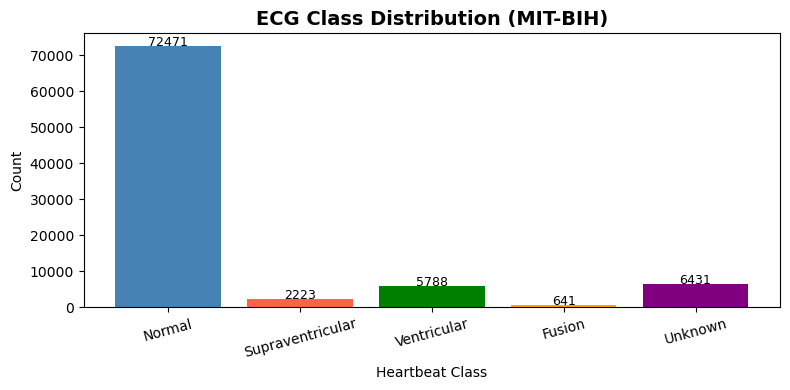

In [3]:
# Load train and test
train_df = pd.read_csv('mitbih_train.csv', header=None)
test_df  = pd.read_csv('mitbih_test.csv',  header=None)

print("Train shape:", train_df.shape)
print("Test  shape:", test_df.shape)

# Last column is the label
print("\nClass Distribution (Train):")
print(train_df[187].value_counts())

# Class names
class_names = {
    0: 'Normal',
    1: 'Supraventricular',
    2: 'Ventricular',
    3: 'Fusion',
    4: 'Unknown'
}

# Plot class distribution
plt.figure(figsize=(8, 4))
counts = train_df[187].value_counts().sort_index()
bars = plt.bar([class_names[i] for i in counts.index],
               counts.values,
               color=['steelblue','tomato','green','orange','purple'])
plt.title('ECG Class Distribution (MIT-BIH)', fontsize=14, fontweight='bold')
plt.xlabel('Heartbeat Class')
plt.ylabel('Count')
plt.xticks(rotation=15)
for bar, val in zip(bars, counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
             str(val), ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150)
plt.show()

CELL 4 — Visualize Sample ECG Signals

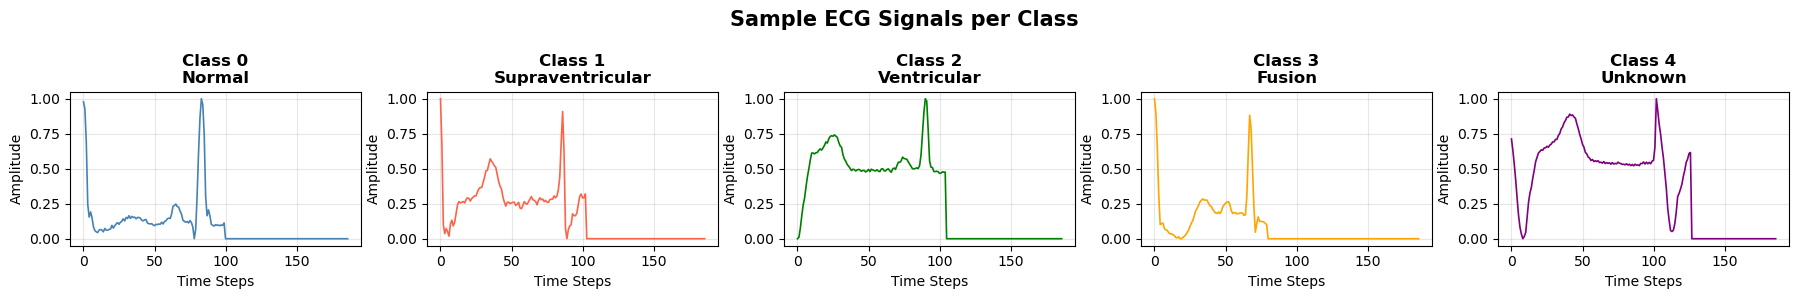

In [6]:
# Show one sample per class
fig, axes = plt.subplots(1, 5, figsize=(18, 3))
colors = ['steelblue','tomato','green','orange','purple']

for i in range(5):
    sample = train_df[train_df[187] == i].iloc[0, :187].values
    axes[i].plot(sample, color=colors[i], linewidth=1.2)
    axes[i].set_title(f'Class {i}\n{class_names[i]}', fontweight='bold')
    axes[i].set_xlabel('Time Steps')
    axes[i].set_ylabel('Amplitude')
    axes[i].grid(True, alpha=0.3)

plt.suptitle('Sample ECG Signals per Class', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('sample_ecg_signals.png', dpi=150)
plt.show()

CELL 5 — Preprocessing & Balancing

In [ ]:
# Split features and labels
X_train = train_df.iloc[:, :187].values
y_train = train_df[187].values.astype(int)

X_test  = test_df.iloc[:, :187].values
y_test  = test_df[187].values.astype(int)

# Balance classes using oversampling (fix class imbalance)
from collections import Counter
print("Before balancing:", Counter(y_train))

# Oversample minority classes to match majority class
df_train = pd.DataFrame(X_train)
df_train['label'] = y_train

majority_count = df_train['label'].value_counts().max()
balanced_dfs = []

for cls in range(5):
    cls_df = df_train[df_train['label'] == cls]
    cls_resampled = resample(cls_df,
                             replace=True,
                             n_samples=majority_count,
                             random_state=42)
    balanced_dfs.append(cls_resampled)

df_balanced = pd.concat(balanced_dfs).sample(frac=1, random_state=42)

X_train = df_balanced.iloc[:, :187].values
y_train = df_balanced['label'].values.astype(int)

print("After balancing :", Counter(y_train))

# Reshape for CNN1D → (samples, timesteps, channels)
X_train = X_train.reshape(X_train.shape[0], 187, 1)
X_test  = X_test.reshape(X_test.shape[0],  187, 1)

# One-hot encode labels
y_train_cat = to_categorical(y_train, num_classes=5)
y_test_cat  = to_categorical(y_test,  num_classes=5)

print("\nX_train shape:", X_train.shape)
print("y_train shape:", y_train_cat.shape)

Before balancing: Counter({np.int64(0): 72471, np.int64(4): 6431, np.int64(2): 5788, np.int64(1): 2223, np.int64(3): 641})
After balancing : Counter({np.int64(3): 72471, np.int64(2): 72471, np.int64(4): 72471, np.int64(1): 72471, np.int64(0): 72471})

X_train shape: (362355, 187, 1)
y_train shape: (362355, 5)


CELL 6 — Build CNN 1D Model

In [ ]:
model = Sequential([

    # Block 1
    Conv1D(filters=64, kernel_size=5, activation='relu',
           padding='same', input_shape=(187, 1)),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),
    Dropout(0.25),

    # Block 2
    Conv1D(filters=128, kernel_size=5, activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),
    Dropout(0.25),

    # Block 3
    Conv1D(filters=256, kernel_size=3, activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),
    Dropout(0.3),

    # Flatten + Dense
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.4),
    Dense(64, activation='relu'),

    # Output
    Dense(5, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

c:\Users\ABHINAV\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 187, 64)        │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 187, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 93, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 93, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 93, 128)        │        41,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 93, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 46, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 46, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 46, 256)        │        98,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 46, 256)        │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 23, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 23, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 5888)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       753,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 904,197 (3.45 MB)

 Trainable params: 903,301 (3.45 MB)

 Non-trainable params: 896 (3.50 KB)

CELL 7 — Train the Model

In [ ]:
# Callbacks
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=8,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=4,
    min_lr=1e-6,
    verbose=1
)

# Train
history = model.fit(
    X_train, y_train_cat,
    epochs=50,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

print("\n✅ CNN1D Training Complete!")

Epoch 1/50
4530/4530 ━━━━━━━━━━━━━━━━━━━━ 198s 43ms/step - accuracy: 0.9074 - loss: 0.2553 - val_accuracy: 0.9684 - val_loss: 0.0918 - learning_rate: 0.0010
Epoch 2/50
4530/4530 ━━━━━━━━━━━━━━━━━━━━ 179s 39ms/step - accuracy: 0.9617 - loss: 0.1079 - val_accuracy: 0.9835 - val_loss: 0.0490 - learning_rate: 0.0010
Epoch 3/50
4530/4530 ━━━━━━━━━━━━━━━━━━━━ 174s 38ms/step - accuracy: 0.9728 - loss: 0.0780 - val_accuracy: 0.9892 - val_loss: 0.0327 - learning_rate: 0.0010
Epoch 4/50
4530/4530 ━━━━━━━━━━━━━━━━━━━━ 182s 40ms/step - accuracy: 0.9788 - loss: 0.0626 - val_accuracy: 0.9921 - val_loss: 0.0280 - learning_rate: 0.0010
Epoch 5/50
4530/4530 ━━━━━━━━━━━━━━━━━━━━ 186s 41ms/step - accuracy: 0.9826 - loss: 0.0524 - val_accuracy: 0.9922 - val_loss: 0.0241 - learning_rate: 0.0010
Epoch 6/50
4530/4530 ━━━━━━━━━━━━━━━━━━━━ 198s 44ms/step - accuracy: 0.9843 - loss: 0.0471 - val_accuracy: 0.9950 - val_loss: 0.0165 - learning_rate: 0.0010
Epoch 7/50
4530/4530 ━━━━━━━━━━━━━━━━━━━━ 198s 44ms/step -

CELL 8 — Accuracy & Loss Graphs

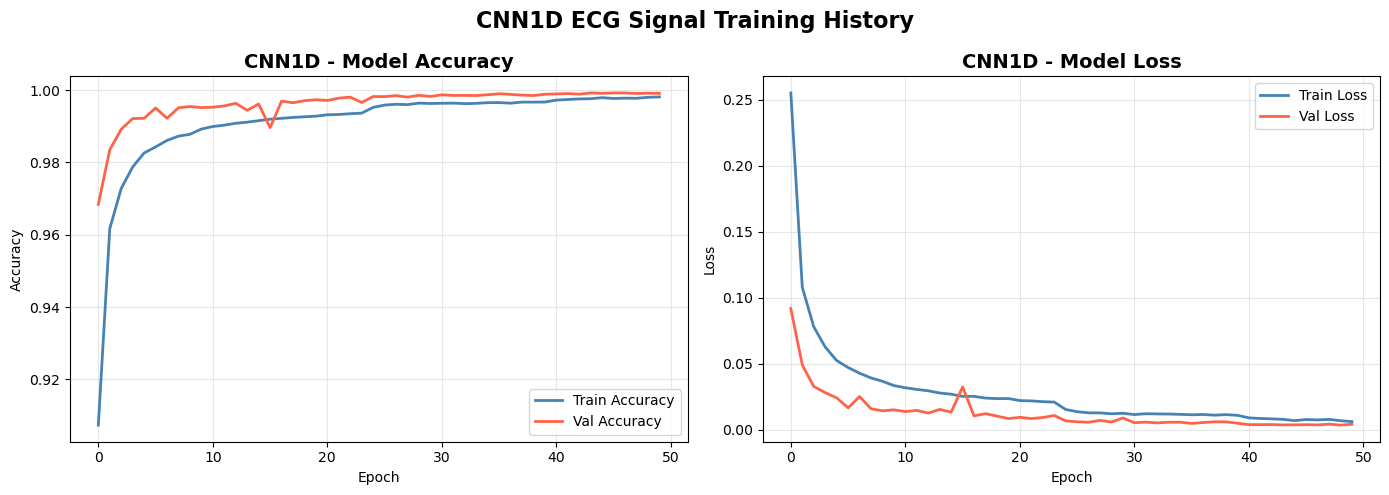

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
axes[0].plot(history.history['accuracy'],
             label='Train Accuracy', color='steelblue', linewidth=2)
axes[0].plot(history.history['val_accuracy'],
             label='Val Accuracy', color='tomato', linewidth=2)
axes[0].set_title('CNN1D - Model Accuracy', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Loss
axes[1].plot(history.history['loss'],
             label='Train Loss', color='steelblue', linewidth=2)
axes[1].plot(history.history['val_loss'],
             label='Val Loss', color='tomato', linewidth=2)
axes[1].set_title('CNN1D - Model Loss', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('CNN1D ECG Signal Training History', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('cnn1d_accuracy_loss.png', dpi=150, bbox_inches='tight')
plt.show()

CELL 9 — Evaluate Model

In [ ]:
# Predict
y_pred_prob = model.predict(X_test)
y_pred = np.argmax(y_pred_prob, axis=1)

# Accuracy
acc = accuracy_score(y_test, y_pred)
print(f"✅ CNN1D Test Accuracy: {acc*100:.2f}%")

# Classification Report
print("\n=== Classification Report ===")
print(classification_report(
    y_test, y_pred,
    target_names=list(class_names.values())
))

685/685 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step
✅ CNN1D Test Accuracy: 98.62%

=== Classification Report ===
                  precision    recall  f1-score   support

          Normal       0.99      0.99      0.99     18118
Supraventricular       0.87      0.84      0.86       556
     Ventricular       0.96      0.97      0.96      1448
          Fusion       0.77      0.83      0.80       162
         Unknown       0.99      0.99      0.99      1608

        accuracy                           0.99     21892
       macro avg       0.92      0.92      0.92     21892
    weighted avg       0.99      0.99      0.99     21892



CELL 10 — Confusion Matrix

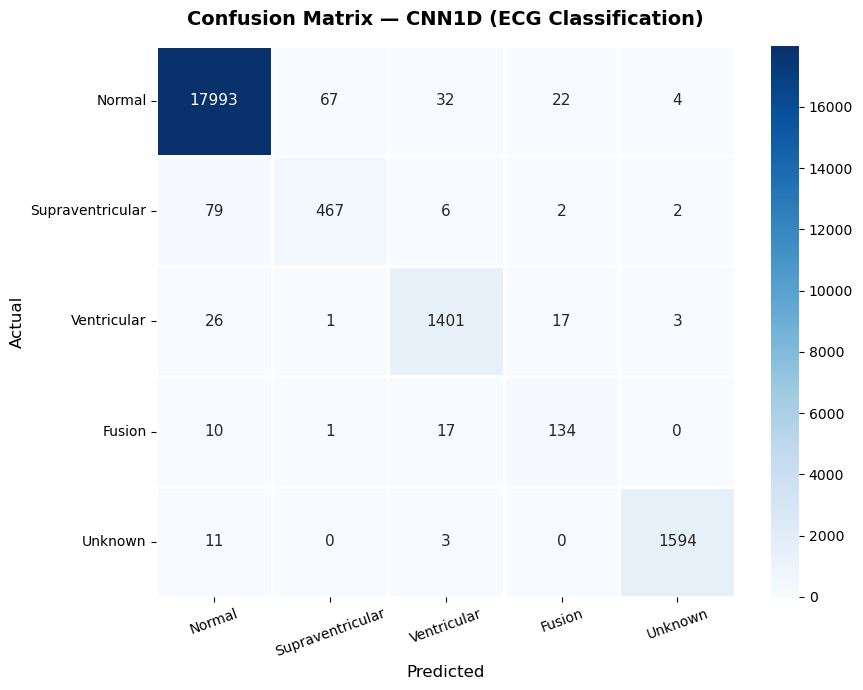

In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=list(class_names.values()),
            yticklabels=list(class_names.values()),
            linewidths=0.8, linecolor='white',
            annot_kws={"size": 11})

plt.title('Confusion Matrix — CNN1D (ECG Classification)',
          fontsize=14, fontweight='bold', pad=15)
plt.ylabel('Actual',    fontsize=12)
plt.xlabel('Predicted', fontsize=12)
plt.xticks(rotation=20)
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('cnn1d_confusion_matrix.png', dpi=150)
plt.show()

CELL 11 — Per-Class Accuracy Bar Chart

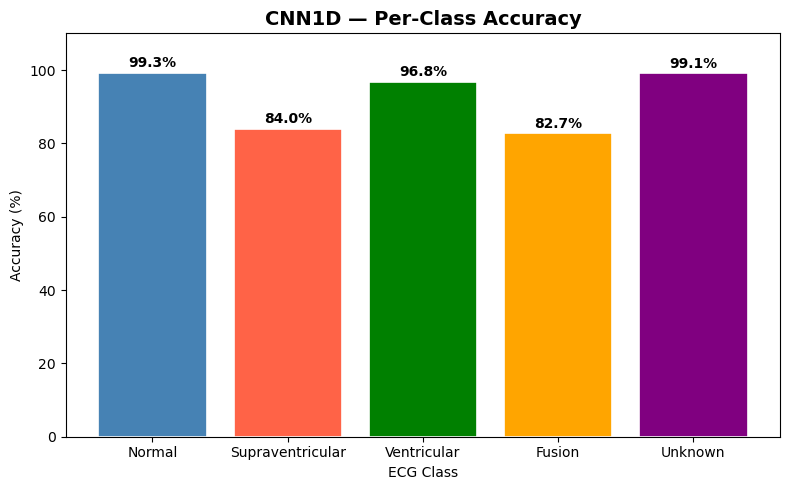

In [ ]:
# Per-class accuracy
per_class_acc = cm.diagonal() / cm.sum(axis=1)

plt.figure(figsize=(8, 5))
bars = plt.bar(
    list(class_names.values()),
    per_class_acc * 100,
    color=['steelblue','tomato','green','orange','purple'],
    edgecolor='white', linewidth=1.2
)
plt.title('CNN1D — Per-Class Accuracy', fontsize=14, fontweight='bold')
plt.xlabel('ECG Class')
plt.ylabel('Accuracy (%)')
plt.ylim(0, 110)
for bar, acc_val in zip(bars, per_class_acc):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 1.5,
             f'{acc_val*100:.1f}%',
             ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('cnn1d_per_class_accuracy.png', dpi=150)
plt.show()

CELL 12 — Save Model & Download Graphs

In [ ]:
# Download everything
model.save('cnn1d_ecg_model.h5')
print("✅ Model saved!")

from IPython.display import FileLink, display

for fname in [
    'cnn1d_accuracy_loss.png',
    'cnn1d_confusion_matrix.png',
    'cnn1d_per_class_accuracy.png',
    'sample_ecg_signals.png',
    'class_distribution.png',
    'cnn1d_ecg_model.h5',
]:
    display(FileLink(fname))

✅ Model saved!


c:\Users\ABHINAV\Desktop\Heart_PA\cnn1d_accuracy_loss.png

c:\Users\ABHINAV\Desktop\Heart_PA\cnn1d_confusion_matrix.png

c:\Users\ABHINAV\Desktop\Heart_PA\cnn1d_per_class_accuracy.png

c:\Users\ABHINAV\Desktop\Heart_PA\sample_ecg_signals.png

c:\Users\ABHINAV\Desktop\Heart_PA\class_distribution.png

c:\Users\ABHINAV\Desktop\Heart_PA\cnn1d_ecg_model.h5